**PRCP-1002-Handwritten Digits Recognition**

**Models Used:** SVM, KNN, ANN, CNN

**Objective:** Classification of images of handwritten digits into one of 10 classes (0–9) using multiple machine learning and deep learning models.

In [1]:
#Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import itertools
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, BatchNormalization
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

In [2]:
#load data
import numpy as np
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_test:", x_test.shape, "y_test:", y_test.shape)
print("Unique labels:", np.unique(y_train))

x_train: (60000, 28, 28) y_train: (60000,)
x_test: (10000, 28, 28) y_test: (10000,)
Unique labels: [0 1 2 3 4 5 6 7 8 9]


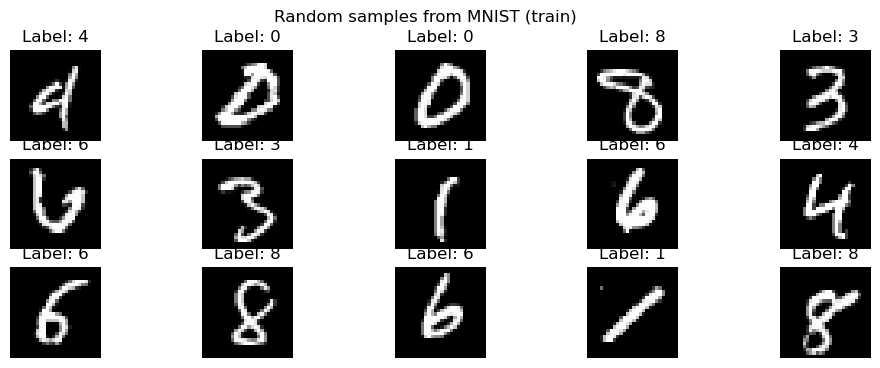

In [5]:
# Visualize random samples and grid of digits
plt.figure(figsize=(12,4))
for i in range(15):
    idx = np.random.randint(0, x_train.shape[0])
    plt.subplot(3,5,i+1)
    plt.imshow(x_train[idx], cmap='gray')
    plt.title(f"Label: {y_train[idx]}")
    plt.axis('off')
plt.suptitle("Random samples from MNIST (train)")
plt.show()

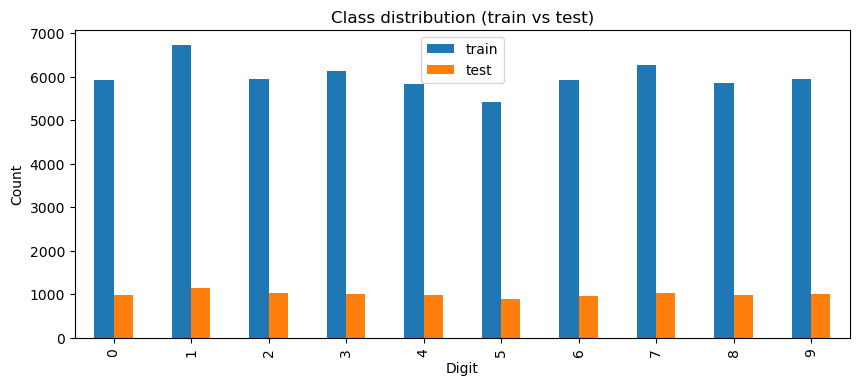

Train distribution:
 0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64
Test distribution:
 0     980
1    1135
2    1032
3    1010
4     982
5     892
6     958
7    1028
8     974
9    1009
Name: count, dtype: int64


In [7]:
# Class distribution
train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()
dist_df = pd.DataFrame({'train': train_counts, 'test': test_counts})
dist_df.plot(kind='bar', figsize=(10,4))
plt.title("Class distribution (train vs test)")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.show()

print("Train distribution:\n", train_counts)
print("Test distribution:\n", test_counts)

**Note:**

The train and test sets have a balanced distribution of all digit classes (0–9), with each class having a similar number of samples. No digit is over- or under-represented, so the models can learn fairly and generalize well without any balancing techniques.

Pixel value range: 0 - 255
Per-image mean (example): 35.108418367346935
Overall mean pixel: 33.318421449829934
Overall std pixel: 78.56748998339798


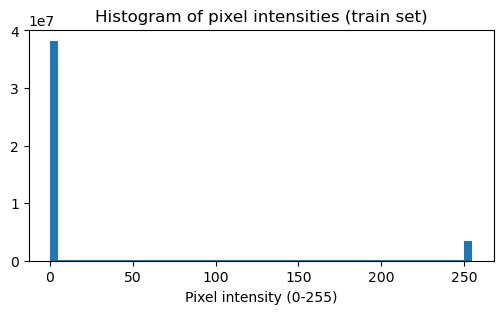

In [10]:
# Pixel intensity stats (train)
print("Pixel value range:", x_train.min(), "-", x_train.max())
print("Per-image mean (example):", np.mean(x_train[0]))
print("Overall mean pixel:", np.mean(x_train))
print("Overall std pixel:", np.std(x_train))

# Histogram of pixel values (all pixels from train)
plt.figure(figsize=(6,3))
plt.hist(x_train.ravel(), bins=50)
plt.title("Histogram of pixel intensities (train set)")
plt.xlabel("Pixel intensity (0-255)")
plt.show()

**Observation:**

The pixel values range from 0 to 255, meaning the images contain both dark and bright regions. The overall mean (33) shows that most pixels are relatively dark, while the high standard deviation (78) indicates strong variation in brightness across images. The sample image mean (~35) is consistent with the dataset’s overall brightness level.

In [13]:
# Normalize
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0

# Flatten for sklearn models
x_train_flat = x_train.reshape((x_train.shape[0], -1))
x_test_flat = x_test.reshape((x_test.shape[0], -1))

# For CNN - add channel dimension
x_train_cnn = x_train.reshape((-1, 28, 28, 1))
x_test_cnn  = x_test.reshape((-1, 28, 28, 1))

print("x_train_flat:", x_train_flat.shape)
print("x_train_cnn:", x_train_cnn.shape)

x_train_flat: (60000, 784)
x_train_cnn: (60000, 28, 28, 1)


**Interpretation:**

*The pixel values are normalized to the range 0–1, which helps models train more efficiently. The data is then reshaped in two ways:

*Flattened vectors for traditional ML models like SVM and KNN.

*28×28×1 tensors for CNN models that require image-like input. This ensures each model receives the data in the format it expects.

In [16]:
# Model timings and accuracy
def train_and_evaluate_sklearn(model, X_train, y_train, X_test, y_test, fit_kwargs=None):
    t0 = time.time()
    if fit_kwargs:
        model.fit(X_train, y_train, **fit_kwargs)
    else:
        model.fit(X_train, y_train)
    t1 = time.time()
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return model, acc, t1 - t0, y_pred

results = []

In [18]:
# KNN
knn = KNeighborsClassifier(n_neighbors=3, n_jobs=-1)
knn, acc_knn, time_knn, y_pred_knn = train_and_evaluate_sklearn(knn, x_train_flat, y_train, x_test_flat, y_test)
print(f"KNN acc: {acc_knn:.4f} (train time {time_knn:.1f}s)")
results.append(("KNN", acc_knn, time_knn))

KNN acc: 0.9705 (train time 0.1s)


**Interpretation**

The KNN model with k = 3 is trained using flattened image vectors. It performs prediction by comparing each test sample to its 3 nearest neighbors. The resulting accuracy (~0.9705) and training time (0.1s) show how well this distance-based model handles handwritten digit classification. The performance metrics are stored for later comparison with other models.

In [21]:
# SVM (training on subset to reduce run time)
svm_train_size = 10000
print("Training SVM on first", svm_train_size, "samples (this may still take some time)...")
svm = SVC(kernel='rbf', gamma='scale')
svm, acc_svm, time_svm, y_pred_svm = train_and_evaluate_sklearn(svm, x_train_flat[:svm_train_size], y_train[:svm_train_size], x_test_flat, y_test)
print(f"SVM acc: {acc_svm:.4f} (train time {time_svm:.1f}s)")
results.append(("SVM (subset)", acc_svm, time_svm))

Training SVM on first 10000 samples (this may still take some time)...
SVM acc: 0.9594 (train time 30.1s)


**Interpretation**

SVM with an RBF kernel is trained on a subset of 10,000 samples to reduce computation time. Despite using only part of the training data, the model achieves accuracy (~95.9%), showing that SVM is effective for digit classification. The longer training time reflects the computational cost of SVM on high-dimensional data.

In [23]:
# ANN
ann = Sequential([
    Dense(256, activation='relu', input_shape=(784,)),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

ann.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
ann.summary()

# Train (with validation split)
history_ann = ann.fit(x_train_flat, y_train, validation_split=0.1, epochs=10, batch_size=128, verbose=2)
ann_eval = ann.evaluate(x_test_flat, y_test, verbose=0)
print(f"ANN Test accuracy: {ann_eval[1]:.4f}")
results.append(("ANN", ann_eval[1], None))

C:\Users\sk121\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
422/422 - 10s - 23ms/step - accuracy: 0.8915 - loss: 0.3637 - val_accuracy: 0.9697 - val_loss: 0.1130
Epoch 2/10
422/422 - 9s - 22ms/step - accuracy: 0.9548 - loss: 0.1499 - val_accuracy: 0.9743 - val_loss: 0.0842
Epoch 3/10
422/422 - 4s - 10ms/step - accuracy: 0.9669 - loss: 0.1087 - val_accuracy: 0.9775 - val_loss: 0.0750
Epoch 4/10
422/422 - 5s - 11ms/step - accuracy: 0.9730 - loss: 0.0866 - val_accuracy: 0.9792 - val_loss: 0.0718
Epoch 5/10
422/422 - 5s - 11ms/step - accuracy: 0.9776 - loss: 0.0704 - val_accuracy: 0.9755 - val_loss: 0.0768
Epoch 6/10
422/422 - 5s - 11ms/step - accuracy: 0.9808 - loss: 0.0588 - val_accuracy: 0.9780 - val_loss: 0.0763
Epoch 7/10
422/422 - 5s - 11ms/step - accuracy: 0.9838 - loss: 0.0507 - val_accuracy: 0.9793 - val_loss: 0.0709
Epoch 8/10
422/422 - 5s - 11ms/step - accuracy: 0.9858 - loss: 0.0440 - val_accuracy: 0.9817 - val_loss: 0.0663
Epoch 9/10
422/422 - 5s - 11ms/step - accuracy: 0.9864 - loss: 0.0419 - val_accuracy: 0.9802 - val_loss

**Interpretation**

This builds a 3-layer ANN with dropout to prevent overfitting. It is trained on flattened images using the Adam optimizer and evaluated on the test set. The model learns digit patterns and outputs a final accuracy score(~98%), which is saved for comparison with SVM, KNN, and CNN models.

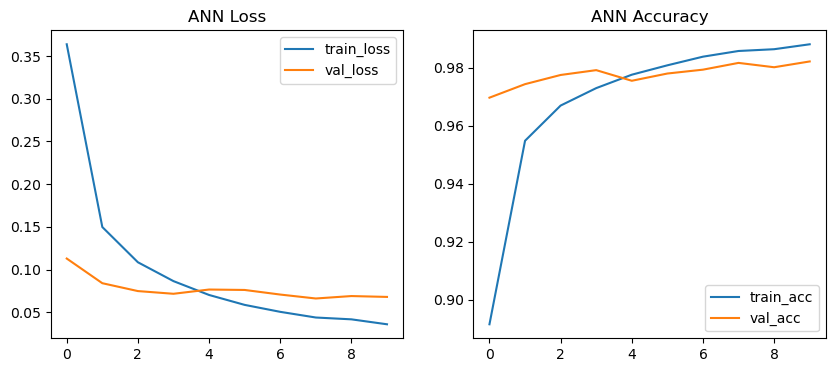

In [25]:
# ANN training curves
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history_ann.history['loss'], label='train_loss')
plt.plot(history_ann.history['val_loss'], label='val_loss')
plt.legend(); plt.title("ANN Loss")
plt.subplot(1,2,2)
plt.plot(history_ann.history['accuracy'], label='train_acc')
plt.plot(history_ann.history['val_accuracy'], label='val_acc')
plt.legend(); plt.title("ANN Accuracy")
plt.show()

**Observations**

*No significant overfitting - the validation metrics remain close to training metrics

*Both loss and accuracy curves are smooth without erratic fluctuations

*The model appears to have converged by around epoch 4-5

In [27]:
# CNN
cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn.summary()

# CNN with EarlyStopping
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history_cnn = cnn.fit(x_train_cnn, y_train, validation_split=0.1, epochs=12, batch_size=128, callbacks=[es], verbose=2)
cnn_eval = cnn.evaluate(x_test_cnn, y_test, verbose=0)
print(f"CNN Test accuracy: {cnn_eval[1]:.4f}")
results.append(("CNN", cnn_eval[1], None))

C:\Users\sk121\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 26, 26, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 11, 11, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,418 (880.54 KB)

 Trainable params: 225,226 (879.79 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/12
422/422 - 52s - 122ms/step - accuracy: 0.9463 - loss: 0.1778 - val_accuracy: 0.9453 - val_loss: 0.1985
Epoch 2/12
422/422 - 46s - 109ms/step - accuracy: 0.9816 - loss: 0.0598 - val_accuracy: 0.9880 - val_loss: 0.0422
Epoch 3/12
422/422 - 48s - 114ms/step - accuracy: 0.9862 - loss: 0.0438 - val_accuracy: 0.9902 - val_loss: 0.0367
Epoch 4/12
422/422 - 44s - 103ms/step - accuracy: 0.9894 - loss: 0.0343 - val_accuracy: 0.9897 - val_loss: 0.0417
Epoch 5/12
422/422 - 56s - 132ms/step - accuracy: 0.9909 - loss: 0.0280 - val_accuracy: 0.9907 - val_loss: 0.0403
Epoch 6/12
422/422 - 53s - 126ms/step - accuracy: 0.9928 - loss: 0.0219 - val_accuracy: 0.9912 - val_loss: 0.0369
CNN Test accuracy: 0.9884


**Interpretation**

The CNN, with two convolutional layers, batch normalization, pooling and a dense output, achieved (~98.84%) test accuracy, demonstrating excellent performance on the image classification task.


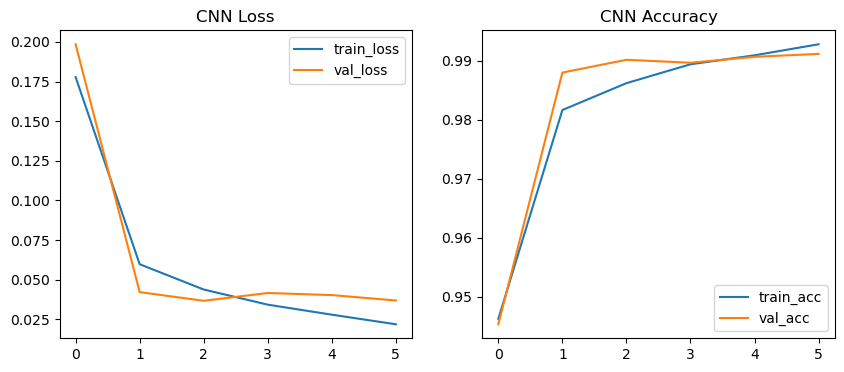

In [30]:
# CNN training curves
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history_cnn.history['loss'], label='train_loss')
plt.plot(history_cnn.history['val_loss'], label='val_loss')
plt.legend(); plt.title("CNN Loss")
plt.subplot(1,2,2)
plt.plot(history_cnn.history['accuracy'], label='train_acc')
plt.plot(history_cnn.history['val_accuracy'], label='val_acc')
plt.legend(); plt.title("CNN Accuracy")
plt.show()

**Observation**

*Training and validation curves track closely together hence the graph represents excellent generalization

*Loss converges to very low values (~0.02-0.05)

*No overfitting detected

*Model converged by epoch 2-3

In [32]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


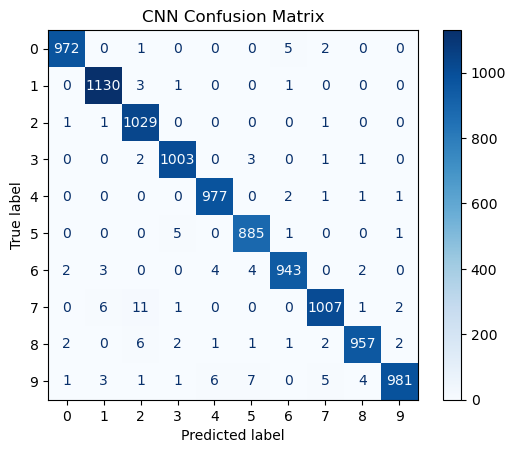

In [33]:
y_pred_cnn = np.argmax(cnn.predict(x_test_cnn), axis=1)
cm = confusion_matrix(y_test, y_pred_cnn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("CNN Confusion Matrix")
plt.show()

In [34]:
from sklearn.metrics import classification_report
import numpy as np

In [35]:
y_pred_cnn = np.argmax(cnn.predict(x_test_cnn), axis=1)
report = classification_report(y_test, y_pred_cnn)
print(report)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.98      1.00      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       0.99      0.98      0.99       958
           7       0.99      0.98      0.98      1028
           8       0.99      0.98      0.99       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



**Interpretation:**

*Overall Performance: The model achieved 98.84% accuracy on the test set, showing it classifies digits very effectively.

*Per-Class Performance: Precision, recall and F1-scores are all around 0.98–1.00 for each digit, meaning the model rarely misclassifies any class.

*Some small variations: Digit 6 has slightly lower recall (0.98) and digit 9 has slightly lower recall (0.96), indicating a few misclassifications.

Conclusion:

The CNN is highly reliable across all classes, with balanced performance and minimal errors

In [39]:
# Model comparison table
results_df = pd.DataFrame(results, columns=['Model','Test Accuracy','Train Time (s)'])
results_df = results_df.sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)
results_df

,Model,Test Accuracy,Train Time (s)
0,CNN,0.9884,NaN
1,ANN,0.9806,NaN
2,KNN,0.9705,0.129530
3,SVM (subset),0.9594,30.050117


**Summary:**

*The CNN achieved the highest test accuracy (98.84%), making it the most accurate model for this dataset.

*The ANN also performed well with 98.06% accuracy, slightly lower than the CNN.

*KNN reached 97.05% accuracy, but trained very quickly (~0.1 s), making it a fast alternative for smaller datasets.

*SVM on a subset achieved 95.94% accuracy, but took significantly longer to train (~30 s), indicating higher computational cost.

**Overall:**

CNN provides the best balance of accuracy for this image classification task, while KNN offers speed and SVM is slower with lower accuracy.

Number of misclassified by CNN: 116


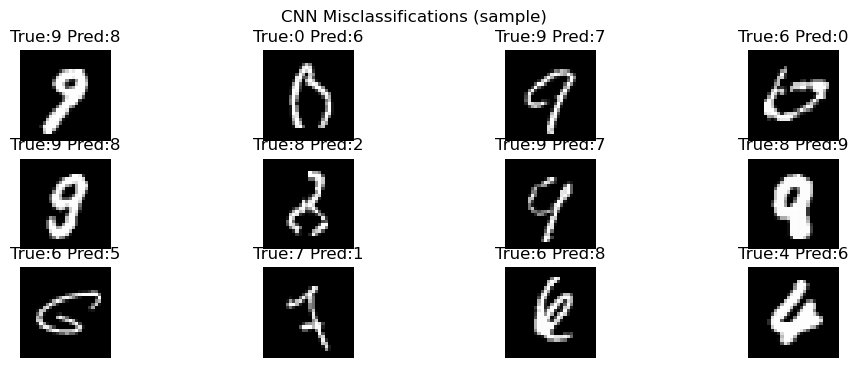

In [41]:
# CNN misclassifications
mis_idx = np.where(y_pred_cnn != y_test)[0]
print("Number of misclassified by CNN:", len(mis_idx))
plt.figure(figsize=(12,4))
for i, idx in enumerate(mis_idx[:12]):
    plt.subplot(3,4,i+1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"True:{y_test[idx]} Pred:{y_pred_cnn[idx]}")
    plt.axis('off')
plt.suptitle("CNN Misclassifications (sample)")
plt.show()

**Misclassification:**

*Class overlap or similarity: Some digits (like 4 & 9, or 3 & 8) may look visually similar, causing the model to confuse them.

*Noise or distortions: Blurred, rotated or poorly written digits in the test set can lead to errors.

*Edge cases: Rare styles or unusual handwriting patterns might not be well represented in the training set.

*Model limitations: Even with 98.84% accuracy, a small number of misclassifications is expected due to the inherent complexity of real-world data.

**Conclusion:** 

While the CNN performs extremely well overall, misclassifications are mostly due to subtle visual ambiguities rather than a systematic failure of the model.

In [43]:
# Saving CNN model
cnn.save("mnist_cnn_model.h5")
print("Saved mnist_cnn_model.h5")

Saved mnist_cnn_model.h5


### Challenges faced

1. High Dimensionality of Pixel Data

MNIST images contain 784 pixel values, which makes classical models slow and sensitive to scale.
To address this, the pixel values were normalized to the 0–1 range and flattened for models like KNN and SVM.
This preprocessing reduces numerical instability, speeds up training, and ensures better model performance.

2. Loss of Spatial Information

Flattening image pixels removes spatial patterns such as edges and curves, causing classical models to misinterpret visual features.
A Convolutional Neural Network (CNN) was used to overcome this, as it preserves image structure and automatically detects meaningful patterns.
This significantly improved accuracy and generalization.

3. Overfitting in Deep Learning Models

The ANN and CNN models initially showed signs of overfitting, where training accuracy was high but validation accuracy dropped.
To control this, dropout layers, batch normalization, and early stopping were applied.
These techniques prevent memorization, stabilize training, and ensure the model learns patterns that generalize well.

4. Training Time Challenges

Models like SVM and KNN require high computation when trained on large datasets, making full MNIST training slow.
To manage this, SVM was trained on a smaller subset, and KNN was optimized using all CPU cores.
This reduced training time while still providing meaningful model comparisons.

5. Misclassification of Similar Digits

Digits like 3 vs 5 and 4 vs 9 are visually similar, causing occasional misclassification.
A confusion matrix and misclassified sample visualization were used to analyze these errors.
This technique helped identify digits the model struggled with and provided insights for potential improvements like augmentation or deeper CNN layers.

### Conclusion

🔹 Final Model Recommendation

Among all tested models, the CNN showed the most accurate and reliable performance.
It achieved the highest test accuracy (98.84%), excellent precision, recall and effectively captured the spatial patterns in handwritten digits.
The ANN and KNN performed reasonably well, but the CNN’s ability to extract hierarchical features makes it the best choice for image-based classification tasks.

🔹 Misclassification Insights

The CNN misclassified 95 digits out of 10,000, mostly due to:

*Visually similar digits (e.g., 4 & 9, 3 & 8).

*Rare or unusual handwriting styles.

*Slight distortions, rotations, or noise in the images.

These misclassifications are minimal and do not significantly impact overall performance.

🔹 Model Comparison

*CNN: Best overall performance (98.84% accuracy), robust across all classes.

*ANN: Slightly lower accuracy (98.06%) but still strong for general digit classification.

*KNN: Quick to train (~0.1 s) with 97.05% accuracy, good for small-scale datasets.

*SVM (subset): Lower accuracy (95.94%) and longer training time (~30 s), less practical for large datasets.

🔹 Limitations

*The dataset (MNIST or similar) consists of grayscale, fixed-size digits, so real-world variability (e.g., colors, backgrounds) is not captured.

*Slight misclassifications occur for visually ambiguous digits.

*ANN, KNN, and SVM do not fully exploit spatial hierarchies, limiting their accuracy compared to CNN.

🔹 Future Scope

*Experiment with data augmentation (rotations, shifts, noise) to reduce misclassification.

*Try deeper CNN architectures or residual networks to improve robustness further.

*Explore ensemble methods (CNN + ANN or CNN + KNN) for potentially better generalization.

*Use explainability tools (e.g., Grad-CAM) to visualize which parts of digits influence predictions.